## BIS ADVANCED

In [1]:
import sys
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import struct

from funciones_aux import *


from matplotlib.colors import LinearSegmentedColormap, PowerNorm

### General todos los archivos

In [2]:
# Exploración carpeta raíz datos advanced

ruta_base_advanced = "../data/data_bis_advanced"

"""for raiz, dirs, files in os.walk(ruta_base_advanced):
    print(f"\nCarpeta: {raiz}")
    print("Subcarpetas:", dirs)
    print("Archivos:", files)"""

'for raiz, dirs, files in os.walk(ruta_base_advanced):\n    print(f"\nCarpeta: {raiz}")\n    print("Subcarpetas:", dirs)\n    print("Archivos:", files)'

In [3]:
ruta_base_advanced = "../data/data_bis_advanced"

"""
os.path.join: construye ruta para el SO
**: buscar en todas las subcarpetas del data_bis_advanced
recursive = True: para que mire en carpeta tras carpeta
    Si no está, ** no te recorre la estructura
glob.glob(...): función para buscar archivos por patrón
"""
todos_archivos_advanced = glob.glob(os.path.join(ruta_base_advanced, "**", "L03041035.*"), recursive=True)

"""for archivo in todos_archivos_advanced:
    probar_apertura_texto(archivo, 5)"""

'for archivo in todos_archivos_advanced:\n    probar_apertura_texto(archivo, 5)'

## .f_a

### Directamente sin pasar por el .csv

In [4]:
archivos_fa = localizar_archivos(ruta_base_advanced, "DH*", "*.f_a")
ruta_fa = archivos_fa[0]
print("Archivo seleccionado:", ruta_fa)

#vista_preeliminar_texto(ruta_fa, 10)

Se han encontrado 2 archivos *.f_a
Archivo seleccionado: ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a


### Carga de archivo
Cargar el archivo .f_a del monitor BIS como un fichero de texto estructurado. 

El separador principal es el carácter |, que delimita una columna temporal (Time) y una columna con la información espectral (Spectra).

La columna Spectra contiene 60 valores por instante temporal, separados por comas, que corresponden a las bandas de frecuencia de la matriz DSA. Estas bandas abarcan desde 0.5 Hz hasta 30 Hz con una resolución de 0.5 Hz.

Una vez expandida la columna espectral, se obtiene una matriz de dimensiones tiempo × frecuencia, que puede representarse como imagen en forma de mapa de calor. En dicha representación, el eje horizontal corresponde al tiempo, el eje vertical a la frecuencia y el color a la intensidad espectral.

La resolución temporal real se verifica calculando la diferencia entre marcas temporales consecutivas. En los datos analizados, esta separación es de 1 segundo por fila.

Los valores espectrales aparecen almacenados como enteros escalados. Tras aplicar un factor de corrección de 1/100, el mapa de color se interpreta como potencia espectral en dB, pendiente de confirmación definitiva con la documentación técnica del dispositivo.

In [5]:
tiempo, dsa = cargar_fa_directo(ruta_fa, escalar_db=True)

print("Dimensiones de la matriz:", dsa.shape)
print("Frecuencias:", dsa.columns.min(), "a", dsa.columns.max(), "Hz")

# salto entre una banda de frecuencia y la siguiente. La diferencia entre columnas consecutivas es 0.5
print("Resolución en frecuencia:", dsa.columns[1] - dsa.columns[0], "Hz")

Dimensiones de la matriz: (2119, 60)
Frecuencias: 0.5 a 30.0 Hz
Resolución en frecuencia: 0.5 Hz


In [6]:
"""
Si se quiere recomponer el df final en el que hay 61 columnas:
 - 1º: Time. Se fuerza a que cuando se convierta en columna se llame Time
 - siguientes: frecuencias de 0.5 Hz a 30 Hz

"""
df_final = pd.concat([tiempo.rename("Time"), dsa], axis=1)
#print(df_final)


### Archivo .spa

In [7]:
ruta_spa_unilat = "../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"
df_spa_unilat = procesar_spa(ruta_spa_unilat)

#display(df_spa_unilat.head())
print(df_spa_unilat.shape)
print(df_spa_unilat.columns.tolist())

(2119, 54)
['Time', 'SpSmooth', 'BiSmooth', 'LoFilter', 'NotFiltr', 'HiFilter', 'PIC_ID', 'SR12', 'SEF08', 'MEDFRQ08', 'BISBIT00', 'DB13U01', 'DB11U04', 'B34U05', 'TOTPOW08', 'EMGLOW01', 'SQI10', 'IMPEDNCE', 'ARTF2', 'BURST', 'ST', 'SR12_2', 'SEF08_2', 'MEDFRQ08_2', 'BISBIT00_2', 'DB13U01_2', 'DB11U04_2', 'B34U05_2', 'TOTPOW08_2', 'EMGLOW01_2', 'SQI10_2', 'IMPEDNCE_2', 'ARTF2_2', 'BURST_2', 'ST_2', 'SR12_3', 'SEF08_3', 'MEDFRQ08_3', 'BISBIT00_3', 'DB13U01_3', 'DB11U04_3', 'B34U05_3', 'TOTPOW08_3', 'EMGLOW01_3', 'SQI10_3', 'IMPEDNCE_3', 'ARTF2_3', 'BURST_3', 'ST_3', 'C1POSIMP', 'C1NEGIMP', 'GNDIMP', 'C2POSIMP', 'C2NEGIMP']


In [71]:
"""display(df_spa_unilat.iloc[200:240: 2, :20])
display(df_spa_unilat.iloc[200: 240: 2, 20:32])
display(df_spa_unilat.iloc[200: 240: 2, 32:43])
display(df_spa_unilat.iloc[200: 240: 2, 43:])"""

'display(df_spa_unilat.iloc[200:240: 2, :20])\ndisplay(df_spa_unilat.iloc[200: 240: 2, 20:32])\ndisplay(df_spa_unilat.iloc[200: 240: 2, 32:43])\ndisplay(df_spa_unilat.iloc[200: 240: 2, 43:])'

#### Cosas de las variables:

 - SpSmooth: Extraído del mensaje de variables procesadas con configuración de suavizado espectral.
     - Formato: 
                0 = 0 seconds
                1 = 5 seconds
                2 = 10 seconds
                3 = 30 seconds
                4 = 60 seconds
 - BiSmooth: Extraído del mensaje de variables procesadas con configuración de suavizado biespectral.
     - Formato:
                0 = 15 seconds
                1 = 30 seconds
                2 = 60 seconds
                3 = 10 seconds
                
 - LoFilter: Mensaje extraído de las variables procesadas con configuración de filtro pasa baja.
     - Formato:
                0 = 0.25 Hz
                1 = 1.00 Hz
                2 = 2.00 Hz
                3 = 2.50 Hz
                
 - NotFilter: Extraído del mensaje de variables procesadas con configuración de filtro de muesca (Notch Filter).
     - Formato:
                0 = ninguno (none)
                1 = 50 Hz
                2 = 60 Hz
                3 = 50 y 60 Hz

 - HiFilter: Extraído del mensaje de variables procesadas con configuración de filtro pasa alta (High Filter).

Formato:
0 = ninguno (none)
1 = 30 Hz
2 = 50 Hz
3 = 70 Hz

 - PIC_ID: ID del cable de interfaz del paciente. Los sensores inteligentes combinan el valor del cable del sensor junto con un valor correspondiente al tipo de sensor.

Formato:
Tipos de sensor = 1 - 14
Cable inteligente = 7
(ej: PIC_ID 27 = Sensor Quatro)

### Sacar Matriz Espectral

In [9]:
def limpiar_spa_para_dsa(df_spa):
    df = df_spa.copy()

    cols = ["SEF08", "MEDFRQ08", "SQI10", "TOTPOW08"]
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [10]:
def construir_mascara_no_valida(df_spa, umbral_sqi=14):
    sqi = pd.to_numeric(df_spa["SQI10"], errors="coerce")
    totpow = pd.to_numeric(df_spa["TOTPOW08"], errors="coerce")

    mask_no_valida = (sqi < umbral_sqi) | (np.isclose(totpow, -327.7))
    return mask_no_valida

In [11]:
def crear_cmap_bis():
    colores_bis = [
        "#001a8f",  # azul oscuro
        "#004cff",  # azul
        "#00c8ff",  # cian
        "#46e6b2",  # verde-agua
        "#d7ef3c",  # amarillo verdoso
        "#ffe100",  # amarillo
        "#ff8c00",  # naranja
        "#d40000",  # rojo
    ]
    cmap = LinearSegmentedColormap.from_list("bis_like", colores_bis, N=256)
    cmap.set_bad(color="white")
    return cmap

### vista tipo PDF BIS

Esta vista intenta parecerse al PDF:

 - tiempo en vertical
 - frecuencia en horizontal
 - mismo mapa de color.
 - líneas discontinuas de bandas EEG


In [12]:
matriz = dsa.values
print(matriz)

[[ 0.    0.    0.   ...  0.    0.    0.  ]
 [ 0.    0.    0.   ...  0.    0.    0.  ]
 [ 0.    0.    0.   ...  0.    0.    0.  ]
 ...
 [90.25 96.09 94.11 ... 78.68 78.69 78.49]
 [90.11 96.01 94.11 ... 78.38 78.48 78.09]
 [89.97 95.94 94.13 ... 78.11 78.27 77.73]]


In [13]:
print("Valor mínimo:", np.nanmin(dsa.values))
print("Valor máximo:", np.nanmax(dsa.values))

Valor mínimo: 0.0
Valor máximo: 103.02


In [14]:
print("Valor mínimo:", dsa.min().min())
print("Valor máximo:", dsa.max().max())

Valor mínimo: 0.0
Valor máximo: 103.02


In [15]:
print(tiempo)

0      2026-03-04 10:35:21
1      2026-03-04 10:35:22
2      2026-03-04 10:35:23
3      2026-03-04 10:35:24
4      2026-03-04 10:35:25
               ...        
2114   2026-03-04 11:10:35
2115   2026-03-04 11:10:36
2116   2026-03-04 11:10:37
2117   2026-03-04 11:10:38
2118   2026-03-04 11:10:39
Name: Time, Length: 2119, dtype: datetime64[ns]


In [16]:
def plot_dsa_pdf_con_spa(tiempo, dsa, df_spa, umbral_sqi=14,
                         vmin=None, vmax=None, gamma=0.55):

    df_spa = limpiar_spa_para_dsa(df_spa)

    # Alinear por tiempo
    df_aux = pd.DataFrame({"Time": tiempo}).reset_index(drop=True)
    df_merge = df_aux.merge(
        df_spa[["Time", "SEF08", "MEDFRQ08", "SQI10", "TOTPOW08"]],
        on="Time",
        how="left"
    )

    sef = df_merge["SEF08"]
    mf = df_merge["MEDFRQ08"]

    dsa_plot = dsa.copy().astype(float)

    # Máscara principal: tramos no válidos
    mask_no_valida = construir_mascara_no_valida(df_merge, umbral_sqi=umbral_sqi)

    # Máscaras auxiliares
    porcentaje_ceros = (dsa_plot == 0).mean(axis=1)
    mask_ceros = porcentaje_ceros > 0.8

    delta_t = tiempo.diff().dt.total_seconds()
    mask_saltos = delta_t.gt(1).fillna(False)

    # Unión de todo
    mask_total = mask_no_valida | mask_ceros | mask_saltos

    dsa_plot.loc[mask_total.values, :] = np.nan

    matriz = dsa_plot.values

    vals = matriz[np.isfinite(matriz)]
    if vmin is None:
        vmin = np.nanpercentile(vals, 2)
    if vmax is None:
        vmax = np.nanpercentile(vals, 99.5)

    norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)
    cmap = crear_cmap_bis()

    fig, ax = plt.subplots(figsize=(4.8, 10))

    y0 = mdates.date2num(tiempo.iloc[0])
    y1 = mdates.date2num(tiempo.iloc[-1])
    x0 = dsa_plot.columns.min()
    x1 = dsa_plot.columns.max()

    im = ax.imshow(
        matriz,
        aspect="auto",
        origin="upper",
        extent=[x0, x1, y1, y0],
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    ax.invert_xaxis()
    ax.yaxis_date()
    ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("Tiempo")
    ax.set_title("DSA", loc="left", fontsize=9, pad=6)

    ax.set_xticks([30, 13, 8, 4])
    ax.set_xticklabels(["30Hz", "13Hz", "8Hz", "4Hz"], fontsize=8)

    for f in [13, 8, 4]:
        ax.axvline(f, color="gray", linestyle="--", linewidth=1, alpha=0.7)

    bandas = {
        "Beta":  (13 + 30) / 2,
        "Alpha": (8 + 13) / 2,
        "Theta": (4 + 8) / 2,
        "Delta": (0.5 + 4) / 2,
    }

    for nombre, xpos in bandas.items():
        ax.text(
            xpos, 1.01, nombre,
            transform=ax.get_xaxis_transform(),
            ha="center", va="bottom",
            fontsize=8, rotation=45
        )

    # Curvas SEF y MF solo con datos válidos
    mask_sef = sef.notna() & (sef >= 0.5) & (sef <= 30)
    mask_mf = mf.notna() & (mf >= 0.5) & (mf <= 30)

    ax.plot(
    sef[mask_sef], tiempo[mask_sef],
    color="white", linewidth=2.0, alpha=0.95, label="SEF"
    )

    ax.plot(
        mf[mask_mf], tiempo[mask_mf],
        color="#7a1fa2", linewidth=2.0, alpha=0.95, label="MEF"
    )
    
    ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.25, 0.92),
    frameon=True,
    facecolor="white",
    framealpha=0.85,
    fontsize=8,
    borderaxespad=0
    )

    cbar = plt.colorbar(im, ax=ax, pad=0.03)
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels(["Min", "Max"])
    cbar.ax.tick_params(length=0)
    cbar.set_label("Intensidad espectral (dB)", rotation=90, labelpad=12)

    plt.tight_layout()
    plt.show()

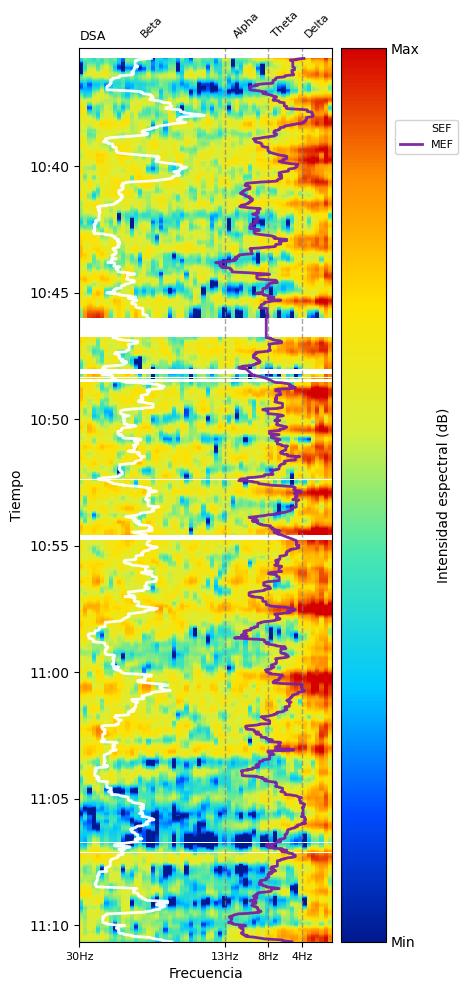

In [17]:
plot_dsa_pdf_con_spa(tiempo, dsa, df_spa_unilat, umbral_sqi=14)

### vista horizontal tipo análisis

In [18]:
def plot_dsa_horizontal_con_spa(
    tiempo,
    dsa,
    df_spa,
    umbral_sqi=14,
    vmin=None,
    vmax=None,
    gamma=0.55
):
    """
    DSA horizontal:
    - eje X = tiempo
    - eje Y = frecuencia
    - usa SEF08 y MEDFRQ08 del .spa
    - enmascara bandas blancas con SQI10 < umbral_sqi o TOTPOW08 == -327.7
    """

    df_spa = limpiar_spa_para_dsa(df_spa)

    # Alinear .spa con la serie temporal de la DSA
    df_aux = pd.DataFrame({"Time": tiempo}).reset_index(drop=True)
    df_merge = df_aux.merge(
        df_spa[["Time", "SEF08", "MEDFRQ08", "SQI10", "TOTPOW08"]],
        on="Time",
        how="left"
    )

    sef = df_merge["SEF08"]
    mf = df_merge["MEDFRQ08"]

    dsa_plot = dsa.copy().astype(float)

    # Máscaras
    mask_no_valida = construir_mascara_no_valida(df_merge, umbral_sqi=umbral_sqi)

    porcentaje_ceros = (dsa_plot == 0).mean(axis=1)
    mask_ceros = porcentaje_ceros > 0.8

    delta_t = tiempo.diff().dt.total_seconds()
    mask_saltos = delta_t.gt(1).fillna(False)

    mask_total = mask_no_valida | mask_ceros | mask_saltos
    dsa_plot.loc[mask_total.values, :] = np.nan

    # Matriz para horizontal: filas = frecuencia, columnas = tiempo
    matriz = dsa_plot.T.values

    vals = matriz[np.isfinite(matriz)]
    if vmin is None:
        vmin = np.nanpercentile(vals, 2)
    if vmax is None:
        vmax = np.nanpercentile(vals, 99.5)

    norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)
    cmap = crear_cmap_bis()

    fig = plt.figure(figsize=(14, 5), constrained_layout=True)
    gs = fig.add_gridspec(1, 3, width_ratios=[20, 1.5, 0.8], wspace=0.08)

    ax = fig.add_subplot(gs[0, 0])       # DSA
    ax_band = fig.add_subplot(gs[0, 1])  # nombres de bandas
    cax = fig.add_subplot(gs[0, 2])      # colorbar

    x0 = mdates.date2num(tiempo.iloc[0])
    x1 = mdates.date2num(tiempo.iloc[-1])
    y0 = dsa_plot.columns.min()
    y1 = dsa_plot.columns.max()

    im = ax.imshow(
        matriz,
        aspect="auto",
        origin="lower",
        extent=[x0, x1, y0, y1],
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    # Curvas SEF y MF
    mask_sef = sef.notna() & (sef >= 0.5) & (sef <= 30)
    mask_mf = mf.notna() & (mf >= 0.5) & (mf <= 30)

    ax.plot(
    tiempo[mask_sef], sef[mask_sef],
    color="white", linewidth=2.0, label="SEF"
    )

    ax.plot(
        tiempo[mask_mf], mf[mask_mf],
        color="#7a1fa2", linewidth=2.0, label="MEF"
    )

    ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=True,
    facecolor="white",
    framealpha=0.8,
    fontsize=9
    )

    # Formato ejes
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    plt.setp(ax.get_xticklabels(), rotation=45)

    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Frecuencia (Hz)")
    ax.set_title("DSA horizontal")

    # Líneas discontinuas de bandas
    for f in [4, 8, 13]:
        ax.axhline(f, color="gray", linestyle="--", linewidth=1, alpha=0.7)

    # Eje lateral para nombres de bandas
    ax_band.set_ylim(y0, y1)
    ax_band.set_xlim(0, 1)
    ax_band.axis("off")

    bandas = {
        "Delta": (0.5 + 4) / 2,
        "Theta": (4 + 8) / 2,
        "Alpha": (8 + 13) / 2,
        "Beta":  (13 + 30) / 2,
    }

    for nombre, ypos in bandas.items():
        ax_band.text(0.05, ypos, nombre, va="center", ha="left", fontsize=9)

    # Barra de color
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels(["Min", "Max"])
    cbar.ax.tick_params(length=0)
    cbar.set_label("Intensidad espectral (dB)", rotation=90, labelpad=12)

    plt.show()

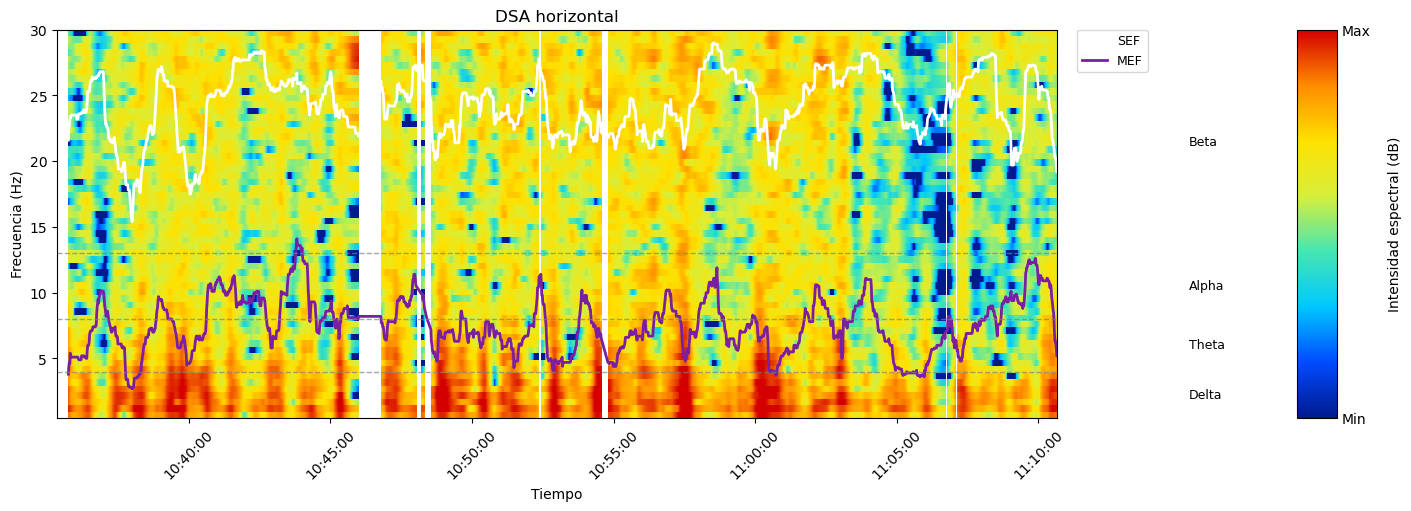

In [19]:
plot_dsa_horizontal_con_spa(tiempo, dsa, df_spa_unilat, umbral_sqi=14, gamma=0.45)

#### Unidades del mapa de color

Los valores espectrales están almacenados escalados por un factor 100 y, tras corregirlo, el mapa de color representa potencia espectral en dB.



#### Resolución temporal real

La resolución temporal real del archivo .f_a es de 1 segundo por fila.

In [62]:
"""plt.figure(figsize=(12,4))
plt.plot(df_spa_unilat["Time"], pd.to_numeric(df_spa_unilat["SQI10"], errors="coerce"))
plt.title("SQI10 a lo largo del tiempo")
plt.ylabel("SQI10")
plt.xlabel("Tiempo")
plt.show()"""

'plt.figure(figsize=(12,4))\nplt.plot(df_spa_unilat["Time"], pd.to_numeric(df_spa_unilat["SQI10"], errors="coerce"))\nplt.title("SQI10 a lo largo del tiempo")\nplt.ylabel("SQI10")\nplt.xlabel("Tiempo")\nplt.show()'

In [61]:
"""plt.figure(figsize=(12,4))
plt.plot(df_spa_unilat["Time"], pd.to_numeric(df_spa_unilat["TOTPOW08"], errors="coerce"))
plt.title("TOTPOW08 a lo largo del tiempo")
plt.ylabel("TOTPOW08")
plt.xlabel("Tiempo")
plt.show()"""

'plt.figure(figsize=(12,4))\nplt.plot(df_spa_unilat["Time"], pd.to_numeric(df_spa_unilat["TOTPOW08"], errors="coerce"))\nplt.title("TOTPOW08 a lo largo del tiempo")\nplt.ylabel("TOTPOW08")\nplt.xlabel("Tiempo")\nplt.show()'

El análisis conjunto de los archivos .f_a y .spa sugiere que las bandas blancas de la DSA no corresponden simplemente a ausencia de filas en la matriz espectral, sino a tramos que el sistema considera no válidos. 

En los datos analizados, estos tramos coinciden con descensos de SQI10 por debajo de aproximadamente 14 y con la aparición del valor centinela -327.7 en TOTPOW08 y -3276.8 DB13U01, interpretado como valor no válido o no disponible. 

Esta interpretación es coherente con el hecho de que el archivo .spa contiene variables procesadas del sistema y con la definición de la DSA como representación de la potencia EEG mediante color.

In [67]:
#resultado_sqi = buscar_filas_por_valor(df_spa_unilat, "SQI10", "between", 13, 14)

In [70]:
resultado_sqi[["Time", "SQI10", "SQI10_3", "TOTPOW08", "TOTPOW08_3", "EMGLOW01", "EMGLOW01_3", "DB13U01", "DB13U01_3"]]

,Time,SQI10,SQI10_3,TOTPOW08,TOTPOW08_3,EMGLOW01,EMGLOW01_3,DB13U01,DB13U01_3
23,2026-03-04 10:35:44,13.3,13.3,-327.7,-327.7,55.6,55.6,-3276.8,-3276.8
650,2026-03-04 10:46:11,13.3,10.0,-327.7,-327.7,64.9,64.9,-3276.8,-3276.8
678,2026-03-04 10:46:39,13.3,13.3,-327.7,-327.7,59.5,59.5,-3276.8,-3276.8
679,2026-03-04 10:46:40,13.3,13.3,-327.7,-327.7,59.3,59.3,-3276.8,-3276.8
680,2026-03-04 10:46:41,13.3,13.3,-327.7,-327.7,59.1,59.1,-3276.8,-3276.8
681,2026-03-04 10:46:42,13.3,13.3,-327.7,-327.7,60.1,60.1,-3276.8,-3276.8
682,2026-03-04 10:46:43,13.3,13.3,-327.7,-327.7,61.6,61.6,-3276.8,-3276.8
683,2026-03-04 10:46:44,13.3,13.3,-327.7,-327.7,63.1,63.1,-3276.8,-3276.8
684,2026-03-04 10:46:45,13.3,13.3,-327.7,-327.7,64.5,64.5,-3276.8,-3276.8
685,2026-03-04 10:46:46,13.3,13.3,-327.7,-327.7,65.7,65.7,-3276.8,-3276.8


In [69]:
"""plt.figure(figsize=(12,4))
plt.plot(df_spa_unilat["Time"], pd.to_numeric(df_spa_unilat["DB13U01"], errors="coerce"))
plt.title("DB13U01 a lo largo del tiempo")
plt.ylabel("DB13U01")
plt.xlabel("Tiempo")
plt.show()"""

'plt.figure(figsize=(12,4))\nplt.plot(df_spa_unilat["Time"], pd.to_numeric(df_spa_unilat["DB13U01"], errors="coerce"))\nplt.title("DB13U01 a lo largo del tiempo")\nplt.ylabel("DB13U01")\nplt.xlabel("Tiempo")\nplt.show()'

#### Limpiar y aislar variables útiles

In [24]:
def preparar_spa_variables(df_spa):
    df = df_spa.copy()

    columnas_interes = [
        "Time",
        "SEF08",
        "MEDFRQ08",
        "EMGLOW01",
        "BURST",
        "DB13U01",
        "SQI10",
        "TOTPOW08",
    ]

    columnas_presentes = [c for c in columnas_interes if c in df.columns]
    df = df[columnas_presentes].copy()

    # Asegurar formato temporal
    if "Time" in df.columns and not pd.api.types.is_datetime64_any_dtype(df["Time"]):
        df["Time"] = pd.to_datetime(df["Time"], errors="coerce")

    # Convertir a numérico
    cols_num = [c for c in df.columns if c != "Time"]
    for col in cols_num:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Centinelas a NaN
    sentinelas = [-327.7, -3276.0, -3276.8, -3276]
    df[cols_num] = df[cols_num].replace(sentinelas, np.nan)

    return df

In [25]:
def enmascarar_tramos_no_validos(df, umbral_sqi=14):
    df_out = df.copy()

    sqi = pd.to_numeric(df_out["SQI10"], errors="coerce") if "SQI10" in df_out.columns else None
    totpow = pd.to_numeric(df_out["TOTPOW08"], errors="coerce") if "TOTPOW08" in df_out.columns else None

    mask = pd.Series(False, index=df_out.index)

    if sqi is not None:
        mask = mask | (sqi < umbral_sqi)

    if totpow is not None:
        mask = mask | np.isclose(totpow, -327.7, equal_nan=False)

    variables_principales = ["SEF08", "MEDFRQ08", "EMGLOW01", "BURST", "DB13U01"]
    for col in variables_principales:
        if col in df_out.columns:
            df_out.loc[mask, col] = np.nan

    return df_out, mask

In [26]:
def figura_dsa_y_variables_alineadas(
    tiempo,
    dsa,
    df_spa,
    umbral_sqi=14,
    vmin=None,
    vmax=None,
    gamma=0.55,
    incluir=("EMGLOW01", "BURST", "DB13U01"),
):
    """
    Figura conjunta con:
    - DSA horizontal arriba
    - variables debajo
    - ejes temporales perfectamente alineados con sharex=True
    """

    df_spa = preparar_spa_variables(df_spa)

    # Alinear spa con tiempo de la DSA
    df_aux = pd.DataFrame({"Time": tiempo}).reset_index(drop=True)
    df_merge = df_aux.merge(
        df_spa,
        on="Time",
        how="left"
    )

    # Variables principales para overlays
    sef = df_merge["SEF08"] if "SEF08" in df_merge.columns else pd.Series(index=df_merge.index, dtype=float)
    mf = df_merge["MEDFRQ08"] if "MEDFRQ08" in df_merge.columns else pd.Series(index=df_merge.index, dtype=float)
    sqi = df_merge["SQI10"] if "SQI10" in df_merge.columns else pd.Series(index=df_merge.index, dtype=float)
    totpow = df_merge["TOTPOW08"] if "TOTPOW08" in df_merge.columns else pd.Series(index=df_merge.index, dtype=float)

    # Enmascarar DSA
    dsa_plot = dsa.copy().astype(float)

    mask_no_valida = (sqi < umbral_sqi) | np.isclose(totpow, -327.7, equal_nan=False)

    porcentaje_ceros = (dsa_plot == 0).mean(axis=1)
    mask_ceros = porcentaje_ceros > 0.8

    delta_t = tiempo.diff().dt.total_seconds()
    mask_saltos = delta_t.gt(1).fillna(False)

    mask_total = mask_no_valida | mask_ceros | mask_saltos
    dsa_plot.loc[mask_total.values, :] = np.nan

    # Enmascarar también variables inferiores
    vars_plot = df_merge.copy()
    for col in ["SEF08", "MEDFRQ08", "EMGLOW01", "BURST", "DB13U01"]:
        if col in vars_plot.columns:
            vars_plot.loc[mask_total.values, col] = np.nan

    matriz = dsa_plot.T.values

    vals = matriz[np.isfinite(matriz)]
    if vmin is None:
        vmin = np.nanpercentile(vals, 2)
    if vmax is None:
        vmax = np.nanpercentile(vals, 99.5)

    norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)
    cmap = crear_cmap_bis()

    n_vars = len(incluir)
    fig = plt.figure(figsize=(15, 3 + 1.8 * n_vars), constrained_layout=True)

    # 3 columnas: gráfico principal, nombres bandas, colorbar
    gs = fig.add_gridspec(
        nrows=1 + n_vars,
        ncols=3,
        width_ratios=[20, 1.5, 0.9],
        height_ratios=[4] + [1] * n_vars,
        wspace=0.05,
        hspace=0.05
    )

    ax_dsa = fig.add_subplot(gs[0, 0])
    ax_band = fig.add_subplot(gs[0, 1])
    cax = fig.add_subplot(gs[0, 2])

    axes_vars = []
    for i in range(n_vars):
        ax = fig.add_subplot(gs[i + 1, 0], sharex=ax_dsa)
        axes_vars.append(ax)

        # ocultar las celdas laterales para filas inferiores
        ax_dummy_band = fig.add_subplot(gs[i + 1, 1])
        ax_dummy_band.axis("off")

        ax_dummy_cbar = fig.add_subplot(gs[i + 1, 2])
        ax_dummy_cbar.axis("off")

    # ---- DSA ----
    x0 = mdates.date2num(tiempo.iloc[0])
    x1 = mdates.date2num(tiempo.iloc[-1])
    y0 = dsa_plot.columns.min()
    y1 = dsa_plot.columns.max()

    im = ax_dsa.imshow(
        matriz,
        aspect="auto",
        origin="lower",
        extent=[x0, x1, y0, y1],
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    mask_sef = sef.notna() & (sef >= 0.5) & (sef <= 30)
    mask_mf = mf.notna() & (mf >= 0.5) & (mf <= 30)

    ax_dsa.plot(
        tiempo[mask_sef], sef[mask_sef],
        color="white", linewidth=2.0, label="SEF"
    )
    ax_dsa.plot(
        tiempo[mask_mf], mf[mask_mf],
        color="#7a1fa2", linewidth=2.0, label="MEF"
    )

    ax_dsa.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
        frameon=True,
        facecolor="white",
        framealpha=0.8,
        fontsize=9
    )

    for f in [4, 8, 13]:
        ax_dsa.axhline(f, color="gray", linestyle="--", linewidth=1, alpha=0.7)

    ax_dsa.set_ylabel("Frecuencia (Hz)")
    ax_dsa.set_title("DSA horizontal")

    # Bandas
    ax_band.set_ylim(y0, y1)
    ax_band.set_xlim(0, 1)
    ax_band.axis("off")

    bandas = {
        "Delta": (0.5 + 4) / 2,
        "Theta": (4 + 8) / 2,
        "Alpha": (8 + 13) / 2,
        "Beta":  (13 + 30) / 2,
    }

    for nombre, ypos in bandas.items():
        ax_band.text(0.05, ypos, nombre, va="center", ha="left", fontsize=9)

    # Colorbar
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels(["Min", "Max"])
    cbar.ax.tick_params(length=0)
    cbar.set_label("Intensidad espectral (dB)", rotation=90, labelpad=12)

    # ---- Variables inferiores ----
    etiquetas = {
        "EMGLOW01": "EMG",
        "BURST": "BURST",
        "DB13U01": "DB13U01",
        "SEF08": "SEF",
        "MEDFRQ08": "MEF",
    }

    for ax, col in zip(axes_vars, incluir):
        if col in vars_plot.columns:
            ax.plot(vars_plot["Time"], vars_plot[col], linewidth=1.5)
        ax.set_ylabel(etiquetas.get(col, col))
        ax.grid(True, axis="y", alpha=0.25)

    # Formato temporal: mismo eje para todos
    ax_dsa.xaxis_date()
    ax_dsa.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

    for ax in [ax_dsa] + axes_vars:
        ax.set_xlim(tiempo.iloc[0], tiempo.iloc[-1])

    # Ocultar etiquetas x salvo en el último
    plt.setp(ax_dsa.get_xticklabels(), visible=False)
    for ax in axes_vars[:-1]:
        plt.setp(ax.get_xticklabels(), visible=False)

    axes_vars[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    plt.setp(axes_vars[-1].get_xticklabels(), rotation=45)
    axes_vars[-1].set_xlabel("Tiempo")

    return fig, [ax_dsa] + axes_vars

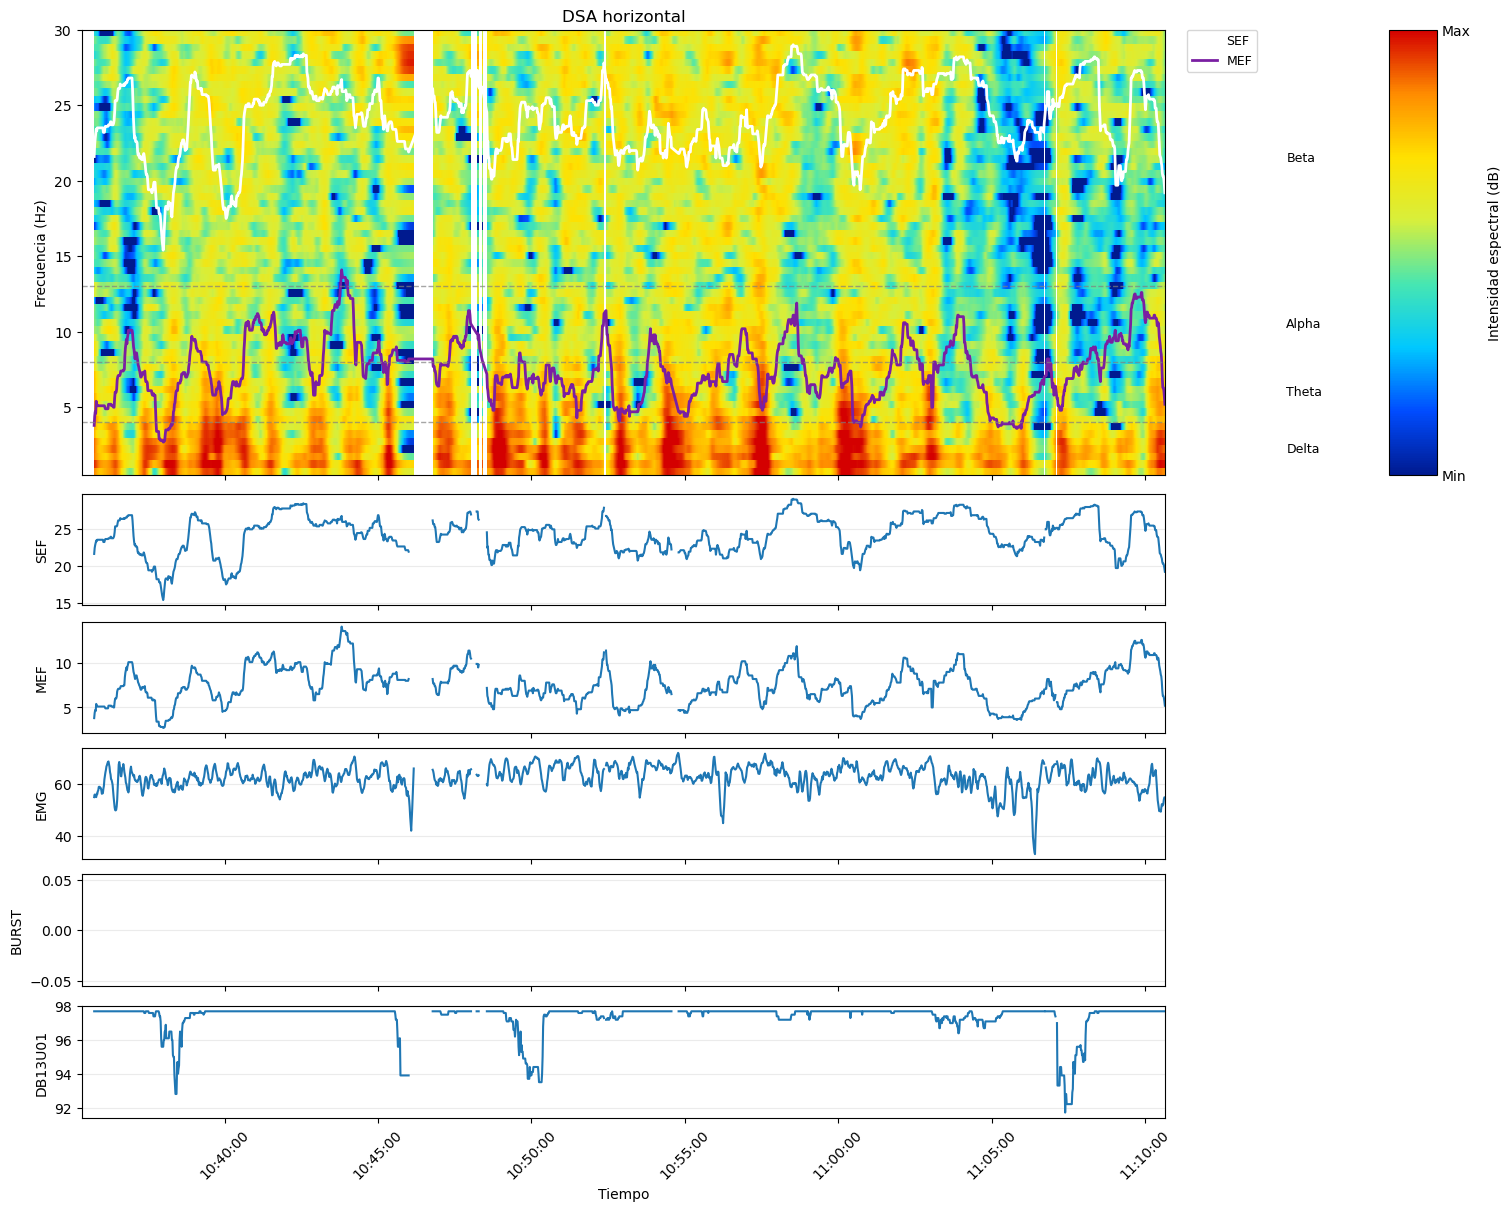

In [27]:

fig, axes = figura_dsa_y_variables_alineadas(
    tiempo,
    dsa,
    df_spa_unilat,
    umbral_sqi=14,
    incluir=("SEF08", "MEDFRQ08", "EMGLOW01", "BURST", "DB13U01")
)

### archivo r2a

In [28]:
archivos_r2a = glob.glob(os.path.join(ruta_base_advanced, "**", "*.r2a"), recursive=True)

In [29]:
archivo_r2a = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"

# Al abrir el archivo, leemos directamente solo los primeros 32 bytes
with open(archivo_r2a, "rb") as archivo:
    primeros_bytes = archivo.read(32)

print("Datos en bruto (Hexadecimal):")
print(primeros_bytes.hex(' '))

Datos en bruto (Hexadecimal):
42 f4 ce f3 f2 f3 cb f2 27 f5 24 f4 69 f4 d6 f4 1e f4 0a f4 46 f4 43 f4 d4 f4 d8 f3 db f5 6e f3


#### Despiece

El manual dice que se ocupan 16 bits a 256 muestras/segundo, pero no aclara explícitamente si eso es por canal o total del módulo. Como el archivo es de 2 canales y la duración real solo cuadra usando 128 Hz por canal, la interpretación más razonable es que el módulo genera 256 muestras/s en total, repartidas como 128 muestras/s por cada uno de los dos canales del archivo r2a.

Se sacan 32 bytes:
 - El monitor graba en 16 bits (2 bytes)
 - El archivo guarda 2 canales entrelazados
 - Se tiene que agrupar de 4 en 4 bytes (2 bytes para el canal 1 y 2 para el canal 2)

Separar los 32 bytes en grupos de 4, obtobtener las primeras 8 muestras:
 - Muestra 1: 42 f4 (Canal 1) | ce f3 (Canal 2)
 - Muestra 2: f2 f3 (Canal 1) | cb f2 (Canal 2)
 - Muestra 3: 27 f5 (Canal 1) | 24 f4 (Canal 2)
 - Muestra 4: 69 f4 (Canal 1) | d6 f4 (Canal 2)

Cada lectura de 4 bytes representa un instante temporal del registro:
- 2 bytes: muestra del canal 1
- 2 bytes: muestra del canal 2

Por tanto, el archivo contiene frames de muestreo de 2 canales entrelazados.
Si el caso dura aproximadamente 35 minutos y el archivo contiene 271312 frames,
la frecuencia temporal compatible es de ~128 frames/s, es decir, 128 muestras/s por canal.

In [30]:
# meter la "r" antes para que lea la ruta tal cual por si hay caracteres especiales
archivo_entrada = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"
archivo_salida = "voltajes_cerebrales_final.csv"

In [31]:
traducir_r2a(archivo_entrada, archivo_salida)

Se procesaron 271312 muestras por canal.
Tiempo total real: 2119.62 segundos.


El archivo .r2a almacena las señales EEG crudas en formato binario con estructura intercalada. En registros de 2 canales, cada instante temporal está formado por dos enteros consecutivos de 16 bits con signo: primero el valor del canal 1 y después el del canal 2. Por tanto, cada frame ocupa 4 bytes. En registros de 4 canales, el patrón de almacenamiento sigue el orden canal 1, canal 2, canal 3 y canal 4, repitiéndose secuencialmente para cada instante de muestreo.

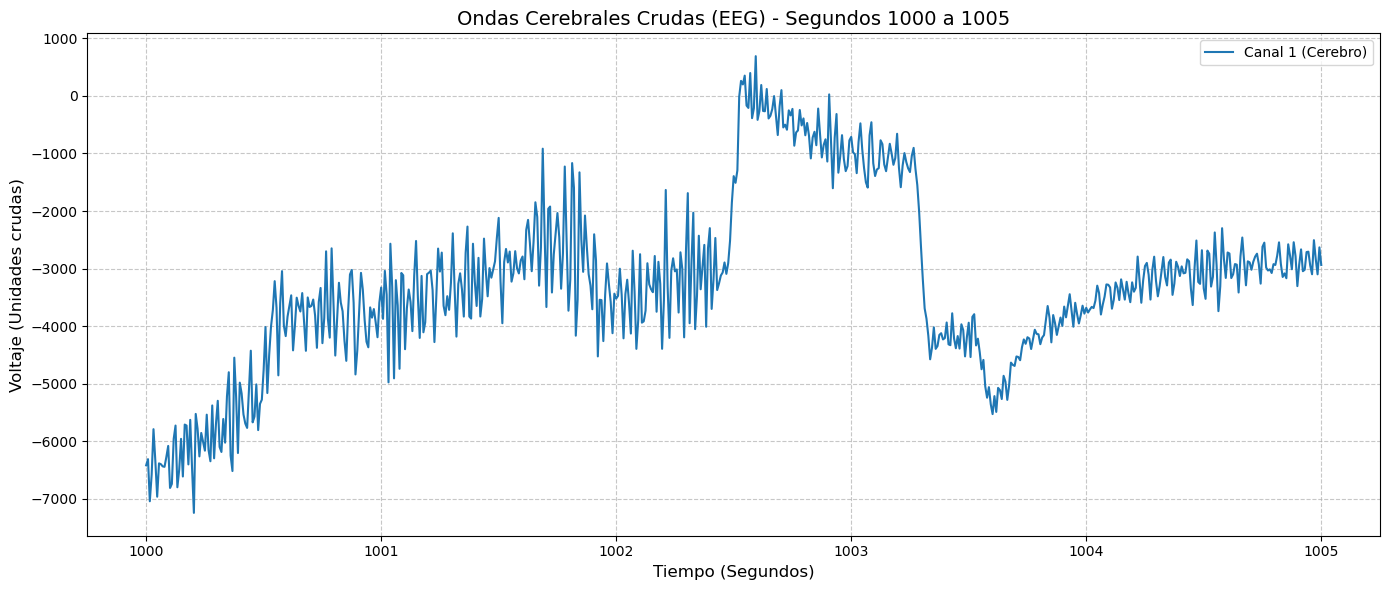

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar archivo CSV
df = pd.read_csv("voltajes_cerebrales_final.csv")

# Elegir ventana de tiempo 
t_inicio = 1000
t_fin = 1005

# Filtramos los datos para coger solo la ventana
df_ventana = df[(df['Tiempo_s'] >= t_inicio) & (df['Tiempo_s'] <= t_fin)]

# crear tamaño figura
plt.figure(figsize=(14, 6))

# dibujar la línea del Canal 1 (cerebro real)
plt.plot(df_ventana['Tiempo_s'], df_ventana['Canal_1'], color='#1f77b4', linewidth=1.5, label='Canal 1 (Cerebro)')

# títulos, etiquetas y cuadrícula
plt.title(f'Ondas Cerebrales Crudas (EEG) - Segundos {t_inicio} a {t_fin}', fontsize=14)
plt.xlabel('Tiempo (Segundos)', fontsize=12)
plt.ylabel('Voltaje (Unidades crudas)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

# Guardar la imagen
plt.tight_layout()
# plt.savefig(f'mis_ondas_eeg_{t_inicio}_a_{t_fin}.png', dpi=300)
plt.show()


### archivo .h_a

In [33]:
archivo_bin = "../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.h_a" 

with open(archivo_bin, "rb") as archivo:
    contenido = archivo.read()

# 2. Vamos a ver los primeros 32 bytes en hexadecimal, separados por espacios
primeros_bytes = contenido[:32]
print("Datos en bruto (Hexadecimal):")
# print(contenido.hex(' '))

Datos en bruto (Hexadecimal):


In [34]:
lectura_h_a(archivo_bin)

ARCHIVO DE CABECERA (.h_a)
--------------------------------------------------
Nombre del archivo:      L03041035.h_a
Hora de inicio deducida: 10:35:
Motor del algoritmo:     BIS-R2
Configuración de Filtro: 0.05 Hz


#### Datos extraídos del Encabezado (.h_a)
 - Nombre del archivo: L03041035.h_a

 - Fecha de inicio de la prueba: 4 de Marzo de 2026 a las 10:35:28 (Hora GMT)

 - Fecha de fin de la prueba: 4 de Marzo de 2026 a las 11:10:45 (Hora GMT)

 - Duración total calculada: 35 minutos y 17 segundos.

 - Motor/Algoritmo del monitor: BIS-R2 (Aparece repetido varias veces en la memoria, indicando la versión del software).

 - Filtro de paso alto configurado: 0.05 Hz (Aparece configurado para los canales internos).

 - Zona Horaria: GMT (Aparece explícitamente escrito casi al final del bloque).

## Dudas teoría Manual BIS Advanced

#### Microvoltios o Decibelios
El archivo crudo (.r2a) es puramente físico: 
 - En la página 32 del manual, define la Amplitud del EEG como la "tensión máxima absoluta de la forma de onda" y especifica claramente que "se expresa en microvoltios (µV)". Por tanto, esos números gigantes que extraíamos del .r2a eran efectivamente subidas y bajadas de microvoltaje puro. 


Las tablas .spa son matemáticas (dB): 
 - El manual confirma en la misma página que el EMG (y consecuentemente la potencia total) "se expresa en decibelios (dB) relativos a 0,0001 µV2". La máquina mide la electricidad bruta en el .r2a (microvoltios) y luego usa ecuaciones complejas para escupir resúmenes en decibelios en el .spa.

#### Tipos de archivos

.r2a y .r4a (EEG sin procesar): 
 - El manual aclara que la "r" es de Raw y el número indica los canales. 
 - El .r2a es para el sistema de 2 canales y el .r4a se genera cuando te ponen el sensor de 4 canales (Bilateral).


.spa (Archivo de variables procesadas): 
 - Aquí enumera que guarda el Índice Biespectral, el EMG, la Calidad de la Señal (ICS) y la Impedancia. Es exactamente la tabla inmensa de Pandas.


.h_a (El Encabezado): 
 - Números hexadecimales. 
 - .h_a incluye: la hora actual del monitor, la revisión de software, 4 números seguidos de -1, el tamaño del archivo crudo, y hora actual en hora Epoch/Unix.


## BIS ANTIGUO

### BIS BILATERAL

In [35]:
ruta_spa_antiguo = "..\data\data_bis_antiguo\L04141330\L04141330.spa"
df_spa_antiguo = procesar_spa(ruta_spa_antiguo)

display(df_spa_antiguo.head())
print(df_spa_antiguo.shape)
print(df_spa_antiguo.columns.tolist())

,Time,SpSmooth,BiSmooth,LoFilter,NotFiltr,HiFilter,PIC_ID,SR12,SEF08,MEDFRQ08,...,C1POSIMP,C1NEGIMP,GNDIMP,C2POSIMP,C2NEGIMP,C3POSIMP,C3NEGIMP,C4POSIMP,C4NEGIMP,BILBITS
0,2026-04-14 13:30:44,3,0,3,3,2,147,0.0,13.4,2.2,...,,,,,,,,,,3
1,2026-04-14 13:30:45,3,0,3,3,2,147,0.0,13.8,2.2,...,,,,,,,,,,3
2,2026-04-14 13:30:46,3,0,3,3,2,147,0.0,14.3,2.3,...,,,,,,,,,,3
3,2026-04-14 13:30:47,3,0,3,3,2,147,0.0,14.6,2.4,...,,,,,,,,,,3
4,2026-04-14 13:30:48,3,0,3,3,2,147,0.0,14.6,2.4,...,,,,,,,,,,3


(5766, 97)
['Time', 'SpSmooth', 'BiSmooth', 'LoFilter', 'NotFiltr', 'HiFilter', 'PIC_ID', 'SR12', 'SEF08', 'MEDFRQ08', 'BISBIT00', 'DB13U01', 'DB11U04', 'B34U05', 'TOTPOW08', 'EMGLOW01', 'SQI10', 'IMPEDNCE', 'ARTF2', 'BURST', 'ST', 'ASYM09', 'SBIS01', 'SEMG01', 'RESVR0', 'RESVR1', 'RESVR2', 'SR12_2', 'SEF08_2', 'MEDFRQ08_2', 'BISBIT00_2', 'DB13U01_2', 'DB11U04_2', 'B34U05_2', 'TOTPOW08_2', 'EMGLOW01_2', 'SQI10_2', 'IMPEDNCE_2', 'ARTF2_2', 'BURST_2', 'ST_2', 'ASYM09_2', 'SBIS01_2', 'SEMG01_2', 'RESVR0_2', 'RESVR1_2', 'RESVR2_2', 'SR12_3', 'SEF08_3', 'MEDFRQ08_3', 'BISBIT00_3', 'DB13U01_3', 'DB11U04_3', 'B34U05_3', 'TOTPOW08_3', 'EMGLOW01_3', 'SQI10_3', 'IMPEDNCE_3', 'ARTF2_3', 'BURST_3', 'ST_3', 'ASYM09_3', 'SBIS01_3', 'SEMG01_3', 'RESVR0_3', 'RESVR1_3', 'RESVR2_3', 'SR12_4', 'SEF08_4', 'MEDFRQ08_4', 'BISBIT00_4', 'DB13U01_4', 'DB11U04_4', 'B34U05_4', 'TOTPOW08_4', 'EMGLOW01_4', 'SQI10_4', 'IMPEDNCE_4', 'ARTF2_4', 'BURST_4', 'ST_4', 'ASYM09_4', 'SBIS01_4', 'SEMG01_4', 'RESVR0_4', 'RESVR

In [36]:
# Contar cuántos segundos se han grabado
print(df_spa_antiguo.shape[0])

5766


In [37]:
display(df_spa_antiguo.iloc[300: 340: 2, :20])

,Time,SpSmooth,BiSmooth,LoFilter,NotFiltr,HiFilter,PIC_ID,SR12,SEF08,MEDFRQ08,BISBIT00,DB13U01,DB11U04,B34U05,TOTPOW08,EMGLOW01,SQI10,IMPEDNCE,ARTF2,BURST
300,2026-04-14 13:35:44,3,0,3,3,2,147,0.0,18.4,3.3,00bc,97.6,-3276.8,-3276.8,64.4,47.5,66.7,2.0,00000280,-3276.8
302,2026-04-14 13:35:46,3,0,3,3,2,147,0.0,18.4,3.3,00ac,97.6,-3276.8,-3276.8,64.4,49.4,64.1,2.8,00000000,-3276.8
304,2026-04-14 13:35:48,3,0,3,3,2,147,0.0,18.4,3.3,00ac,97.6,-3276.8,-3276.8,64.4,51.1,62.8,2.3,00000280,-3276.8
306,2026-04-14 13:35:50,3,0,3,3,2,147,0.0,18.4,3.3,00ac,97.6,-3276.8,-3276.8,64.4,52.2,62.8,2.5,00000080,-3276.8
308,2026-04-14 13:35:52,3,0,3,3,2,147,0.0,17.9,3.2,20a1,97.5,-3276.8,-3276.8,65.6,51.5,64.1,2.1,00000080,-3276.8
310,2026-04-14 13:35:54,3,0,3,3,2,147,0.0,18.3,3.3,20a1,97.5,-3276.8,-3276.8,65.6,52.1,64.1,2.8,00000080,-3276.8
312,2026-04-14 13:35:56,3,0,3,3,2,147,0.0,18.1,3.1,20a1,97.4,-3276.8,-3276.8,65.9,53.3,64.1,2.8,00000080,-3276.8
314,2026-04-14 13:35:58,3,0,3,3,2,147,0.0,18.2,3.2,20a1,97.5,-3276.8,-3276.8,66.3,52.1,64.1,2.3,00000080,-3276.8
316,2026-04-14 13:36:00,3,0,3,3,2,147,0.0,18.2,3.2,20a1,97.5,-3276.8,-3276.8,66.3,50.0,61.5,2.6,00000280,-3276.8
318,2026-04-14 13:36:02,3,0,3,3,2,147,0.0,17.9,3.0,20a1,97.5,-3276.8,-3276.8,66.5,49.3,59.0,2.6,00000200,-3276.8


In [38]:
display(df_spa_antiguo.iloc[300: 340: 2, 20:27])

,ST,ASYM09,SBIS01,SEMG01,RESVR0,RESVR1,RESVR2
300,0,57.1,0.5,-3276.8,0.0,-32768.0,-32768.0
302,0,56.6,0.4,-3276.8,0.0,-32768.0,-32768.0
304,0,56.6,0.3,-3276.8,0.0,-32768.0,-32768.0
306,0,56.6,0.3,-3276.8,0.0,-32768.0,-32768.0
308,0,60.8,0.2,-3276.8,0.0,-32768.0,-32768.0
310,0,58.0,0.1,-3276.8,0.0,-32768.0,-32768.0
312,0,55.8,0.1,-3276.8,0.0,-32768.0,-32768.0
314,0,56.4,0.1,-3276.8,0.0,-32768.0,-32768.0
316,0,57.9,0.1,-3276.8,0.0,-32768.0,-32768.0
318,0,58.1,0.1,-3276.8,0.0,-32768.0,-32768.0


In [39]:
display(df_spa_antiguo.iloc[300: 340: 2, 27:42])

,SR12_2,SEF08_2,MEDFRQ08_2,BISBIT00_2,DB13U01_2,DB11U04_2,B34U05_2,TOTPOW08_2,EMGLOW01_2,SQI10_2,IMPEDNCE_2,ARTF2_2,BURST_2,ST_2,ASYM09_2
300,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.0,00000080,-3276.8,0,-3276.8
302,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.0,00000000,-3276.8,0,-3276.8
304,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.1,00000080,-3276.8,0,-3276.8
306,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.7,00000080,-3276.8,0,-3276.8
308,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.3,00000080,-3276.8,0,-3276.8
310,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.2,00000080,-3276.8,0,-3276.8
312,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.3,00000080,-3276.8,0,-3276.8
314,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,2.6,00000080,-3276.8,0,-3276.8
316,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.5,00000080,-3276.8,0,-3276.8
318,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,0.9,00000000,-3276.8,0,-3276.8


In [40]:
display(df_spa_antiguo.iloc[300: 340: 2, 42:47])

,SBIS01_2,SEMG01_2,RESVR0_2,RESVR1_2,RESVR2_2
300,-3276.8,-3276.8,0.0,-32768.0,-32768.0
302,-3276.8,-3276.8,0.0,-32768.0,-32768.0
304,-3276.8,-3276.8,0.0,-32768.0,-32768.0
306,-3276.8,-3276.8,0.0,-32768.0,-32768.0
308,-3276.8,-3276.8,0.0,-32768.0,-32768.0
310,-3276.8,-3276.8,0.0,-32768.0,-32768.0
312,-3276.8,-3276.8,0.0,-32768.0,-32768.0
314,-3276.8,-3276.8,0.0,-32768.0,-32768.0
316,-3276.8,-3276.8,0.0,-32768.0,-32768.0
318,-3276.8,-3276.8,0.0,-32768.0,-32768.0


In [41]:
display(df_spa_antiguo.iloc[300: 340: 2, 47:62])

,SR12_3,SEF08_3,MEDFRQ08_3,BISBIT00_3,DB13U01_3,DB11U04_3,B34U05_3,TOTPOW08_3,EMGLOW01_3,SQI10_3,IMPEDNCE_3,ARTF2_3,BURST_3,ST_3,ASYM09_3
300,0.0,19.2,3.4,20ac,96.8,-3276.8,-3276.8,63.3,45.7,69.9,2.6,00000280,-3276.8,0,-3276.8
302,0.0,19.2,3.4,20ac,97.1,-3276.8,-3276.8,63.3,47.9,67.3,2.5,00000000,-3276.8,0,-3276.8
304,0.0,19.2,3.4,202c,97.1,-3276.8,-3276.8,63.3,50.7,68.6,2.5,00000280,-3276.8,0,-3276.8
306,0.0,19.2,3.4,202c,97.1,-3276.8,-3276.8,63.3,52.0,67.3,2.2,00000080,-3276.8,0,-3276.8
308,0.0,19.3,3.5,20ac,97.1,-3276.8,-3276.8,63.4,51.1,67.3,2.5,00000080,-3276.8,0,-3276.8
310,0.0,19.6,3.5,20ac,97.1,-3276.8,-3276.8,64.0,51.5,67.3,3.5,00000080,-3276.8,0,-3276.8
312,0.0,19.4,3.4,20ac,97.1,-3276.8,-3276.8,64.6,53.5,69.2,2.9,00000080,-3276.8,0,-3276.8
314,0.0,19.4,3.4,20ac,97.1,-3276.8,-3276.8,64.6,52.5,67.3,3.2,00000080,-3276.8,0,-3276.8
316,0.0,19.9,3.5,20ac,97.2,-3276.8,-3276.8,64.5,50.8,67.3,3.1,00000080,-3276.8,0,-3276.8
318,0.0,19.9,3.5,20ac,97.1,-3276.8,-3276.8,64.5,51.3,64.7,1.6,00000080,-3276.8,0,-3276.8


In [42]:
display(df_spa_antiguo.iloc[300: 340: 2, 62:67])

,SBIS01_3,SEMG01_3,RESVR0_3,RESVR1_3,RESVR2_3
300,1.1,0.0,0.0,-32768.0,-32768.0
302,1.2,0.0,0.0,-32768.0,-32768.0
304,1.2,-3276.8,0.0,-32768.0,-32768.0
306,1.3,-3276.8,0.0,-32768.0,-32768.0
308,1.3,-3276.8,0.0,-32768.0,-32768.0
310,1.3,-3276.8,0.0,-32768.0,-32768.0
312,1.4,-3276.8,0.0,-32768.0,-32768.0
314,1.4,-3276.8,0.0,-32768.0,-32768.0
316,1.4,-3276.8,0.0,-32768.0,-32768.0
318,1.4,-3276.8,0.0,-32768.0,-32768.0


In [43]:
display(df_spa_antiguo.iloc[300: 340: 2, 67:82])

,SR12_4,SEF08_4,MEDFRQ08_4,BISBIT00_4,DB13U01_4,DB11U04_4,B34U05_4,TOTPOW08_4,EMGLOW01_4,SQI10_4,IMPEDNCE_4,ARTF2_4,BURST_4,ST_4,ASYM09_4
300,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.3,00000088,-3276.8,0,-3276.8
302,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.2,00000008,-3276.8,0,-3276.8
304,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.1,00000080,-3276.8,0,-3276.8
306,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.1,00000080,-3276.8,0,-3276.8
308,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.1,00000080,-3276.8,0,-3276.8
310,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.7,00000080,-3276.8,0,-3276.8
312,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.8,00000080,-3276.8,0,-3276.8
314,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,0.9,00000080,-3276.8,0,-3276.8
316,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.0,00000080,-3276.8,0,-3276.8
318,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.8,-3276.8,-327.7,-327.7,100.0,1.1,00000080,-3276.8,0,-3276.8


In [44]:
display(df_spa_antiguo.iloc[300: 340: 2, 82:])

,SBIS01_4,SEMG01_4,RESVR0_4,RESVR1_4,RESVR2_4,C1POSIMP,C1NEGIMP,GNDIMP,C2POSIMP,C2NEGIMP,C3POSIMP,C3NEGIMP,C4POSIMP,C4NEGIMP,BILBITS
300,-3276.8,-3276.8,0.0,-32768.0,-32768.0,,,,,,,,,,3
302,-3276.8,-3276.8,0.0,-32768.0,-32768.0,,,,,,,,,,3
304,-3276.8,-3276.8,0.0,-32768.0,-32768.0,,,,,,,,,,3
306,-3276.8,-3276.8,0.0,-32768.0,-32768.0,,,,,,,,,,3
308,-3276.8,-3276.8,0.0,-32768.0,-32768.0,,,,,,,,,,3
310,-3276.8,-3276.8,0.0,-32768.0,-32768.0,,,,,,,,,,3
312,-3276.8,-3276.8,0.0,-32768.0,-32768.0,,,,,,,,,,3
314,-3276.8,-3276.8,0.0,-32768.0,-32768.0,,,,,,,,,,3
316,-3276.8,-3276.8,0.0,-32768.0,-32768.0,,,,,,,,,,3
318,-3276.8,-3276.8,0.0,-32768.0,-32768.0,,,,,,,,,,3


In [45]:
import funciones_aux

df_spa_limpio = limpiar_spa_bilateral(df_spa_antiguo)

# Comprobamos cómo ha quedado el "antes y después"
print(f"\nForma ANTES de limpiar:  {df_spa_antiguo.shape}")
print(f"Forma DESPUÉS de limpiar: {df_spa_limpio.shape}")

print("\nNuevas columnas limpias listas para el análisis clínico:")
print(df_spa_limpio.columns.tolist())

Iniciando limpieza del archivo .spa...
Se han eliminado 57 columnas basura.

Forma ANTES de limpiar:  (5766, 97)
Forma DESPUÉS de limpiar: (5766, 40)

Nuevas columnas limpias listas para el análisis clínico:
['Time', 'SpSmooth', 'BiSmooth', 'LoFilter', 'NotFiltr', 'HiFilter', 'PIC_ID', 'SR12', 'SEF08', 'MEDFRQ08', 'BISBIT00', 'DB13U01', 'DB11U04', 'B34U05', 'TOTPOW08', 'EMGLOW01', 'SQI10', 'IMPEDNCE', 'ARTF2', 'BURST', 'ST', 'ASYM09', 'SBIS01', 'SEMG01', 'SR12_3', 'SEF08_3', 'MEDFRQ08_3', 'BISBIT00_3', 'DB13U01_3', 'DB11U04_3', 'B34U05_3', 'TOTPOW08_3', 'EMGLOW01_3', 'SQI10_3', 'IMPEDNCE_3', 'ARTF2_3', 'BURST_3', 'ST_3', 'SBIS01_3', 'SEMG01_3']


In [46]:
display(df_spa_limpio.iloc[300: 340: 2, :20])

,Time,SpSmooth,BiSmooth,LoFilter,NotFiltr,HiFilter,PIC_ID,SR12,SEF08,MEDFRQ08,BISBIT00,DB13U01,DB11U04,B34U05,TOTPOW08,EMGLOW01,SQI10,IMPEDNCE,ARTF2,BURST
300,2026-04-14 13:35:44,3,0,3,3,2,147,0.0,18.4,3.3,00bc,97.6,-3276.8,-3276.8,64.4,47.5,66.7,2.0,00000280,-3276.8
302,2026-04-14 13:35:46,3,0,3,3,2,147,0.0,18.4,3.3,00ac,97.6,-3276.8,-3276.8,64.4,49.4,64.1,2.8,00000000,-3276.8
304,2026-04-14 13:35:48,3,0,3,3,2,147,0.0,18.4,3.3,00ac,97.6,-3276.8,-3276.8,64.4,51.1,62.8,2.3,00000280,-3276.8
306,2026-04-14 13:35:50,3,0,3,3,2,147,0.0,18.4,3.3,00ac,97.6,-3276.8,-3276.8,64.4,52.2,62.8,2.5,00000080,-3276.8
308,2026-04-14 13:35:52,3,0,3,3,2,147,0.0,17.9,3.2,20a1,97.5,-3276.8,-3276.8,65.6,51.5,64.1,2.1,00000080,-3276.8
310,2026-04-14 13:35:54,3,0,3,3,2,147,0.0,18.3,3.3,20a1,97.5,-3276.8,-3276.8,65.6,52.1,64.1,2.8,00000080,-3276.8
312,2026-04-14 13:35:56,3,0,3,3,2,147,0.0,18.1,3.1,20a1,97.4,-3276.8,-3276.8,65.9,53.3,64.1,2.8,00000080,-3276.8
314,2026-04-14 13:35:58,3,0,3,3,2,147,0.0,18.2,3.2,20a1,97.5,-3276.8,-3276.8,66.3,52.1,64.1,2.3,00000080,-3276.8
316,2026-04-14 13:36:00,3,0,3,3,2,147,0.0,18.2,3.2,20a1,97.5,-3276.8,-3276.8,66.3,50.0,61.5,2.6,00000280,-3276.8
318,2026-04-14 13:36:02,3,0,3,3,2,147,0.0,17.9,3.0,20a1,97.5,-3276.8,-3276.8,66.5,49.3,59.0,2.6,00000200,-3276.8


In [47]:
display(df_spa_limpio.iloc[300: 340: 2, 20:])

,ST,ASYM09,SBIS01,SEMG01,SR12_3,SEF08_3,MEDFRQ08_3,BISBIT00_3,DB13U01_3,DB11U04_3,B34U05_3,TOTPOW08_3,EMGLOW01_3,SQI10_3,IMPEDNCE_3,ARTF2_3,BURST_3,ST_3,SBIS01_3,SEMG01_3
300,0,57.1,0.5,-3276.8,0.0,19.2,3.4,20ac,96.8,-3276.8,-3276.8,63.3,45.7,69.9,2.6,00000280,-3276.8,0,1.1,0.0
302,0,56.6,0.4,-3276.8,0.0,19.2,3.4,20ac,97.1,-3276.8,-3276.8,63.3,47.9,67.3,2.5,00000000,-3276.8,0,1.2,0.0
304,0,56.6,0.3,-3276.8,0.0,19.2,3.4,202c,97.1,-3276.8,-3276.8,63.3,50.7,68.6,2.5,00000280,-3276.8,0,1.2,-3276.8
306,0,56.6,0.3,-3276.8,0.0,19.2,3.4,202c,97.1,-3276.8,-3276.8,63.3,52.0,67.3,2.2,00000080,-3276.8,0,1.3,-3276.8
308,0,60.8,0.2,-3276.8,0.0,19.3,3.5,20ac,97.1,-3276.8,-3276.8,63.4,51.1,67.3,2.5,00000080,-3276.8,0,1.3,-3276.8
310,0,58.0,0.1,-3276.8,0.0,19.6,3.5,20ac,97.1,-3276.8,-3276.8,64.0,51.5,67.3,3.5,00000080,-3276.8,0,1.3,-3276.8
312,0,55.8,0.1,-3276.8,0.0,19.4,3.4,20ac,97.1,-3276.8,-3276.8,64.6,53.5,69.2,2.9,00000080,-3276.8,0,1.4,-3276.8
314,0,56.4,0.1,-3276.8,0.0,19.4,3.4,20ac,97.1,-3276.8,-3276.8,64.6,52.5,67.3,3.2,00000080,-3276.8,0,1.4,-3276.8
316,0,57.9,0.1,-3276.8,0.0,19.9,3.5,20ac,97.2,-3276.8,-3276.8,64.5,50.8,67.3,3.1,00000080,-3276.8,0,1.4,-3276.8
318,0,58.1,0.1,-3276.8,0.0,19.9,3.5,20ac,97.1,-3276.8,-3276.8,64.5,51.3,64.7,1.6,00000080,-3276.8,0,1.4,-3276.8


In [48]:
import numpy as np

# 1. Extraemos el Tiempo y las 4 columnas clave (Crudo y Suavizado de cada lado)
df_bis_pantalla = df_spa_limpio[['Time', 'DB13U01', 'SBIS01', 'DB13U01_3', 'SBIS01_3']].copy()

# 2. Renombramos para que cualquiera pueda entender la tabla
df_bis_pantalla.columns = [
    'Tiempo', 
    'Izq_BIS_Crudo', 'Izq_BIS_Suavizado', 
    'Der_BIS_Crudo', 'Der_BIS_Suavizado'
]

# 3. Limpiamos los -3276.8 (los segundos iniciales donde no había señal)
df_bis_pantalla.replace(-3276.8, np.nan, inplace=True)

# ¡Y listo! Aquí está la tabla maestra
display(df_bis_pantalla.head(15))

,Tiempo,Izq_BIS_Crudo,Izq_BIS_Suavizado,Der_BIS_Crudo,Der_BIS_Suavizado
0,2026-04-14 13:30:44,97.7,0.1,91.0,3.5
1,2026-04-14 13:30:45,97.7,0.2,92.8,3.4
2,2026-04-14 13:30:46,97.7,0.2,95.5,3.3
3,2026-04-14 13:30:47,97.7,0.2,97.2,3.3
4,2026-04-14 13:30:48,97.7,0.2,97.5,3.5
5,2026-04-14 13:30:49,97.7,0.2,97.4,3.8
6,2026-04-14 13:30:50,97.7,0.2,97.4,4.0
7,2026-04-14 13:30:51,97.7,0.2,97.4,4.1
8,2026-04-14 13:30:52,97.7,0.2,97.4,4.3
9,2026-04-14 13:30:53,97.7,0.2,97.4,4.4


In [49]:

archivo_entrada = r"..\data\data_bis_antiguo\L04141330\L04141330.r4a"
archivo_salida = "voltajes_bilaterales.csv"

print("Iniciando conversión de ondas crudas (BIS Bilateral) a 128 Hz...")

with open(archivo_entrada, "rb") as f_in, open(archivo_salida, "w") as f_out:
    # 1. Ahora tenemos 4 canales en la cabecera
    f_out.write("Tiempo_s,Canal_1,Canal_2,Canal_3,Canal_4\n")
    
    contador_muestras = 0
    
    # 2. Leemos de 8 en 8 bytes (4 canales * 2 bytes/canal)
    while True:
        bytes_muestra = f_in.read(8)
        if not bytes_muestra or len(bytes_muestra) < 8:
            break
        
        # 3. El molde crece: '<hhhh' significa "sácame CUATRO números de 16 bits"
        canal_1, canal_2, canal_3, canal_4 = struct.unpack('<hhhh', bytes_muestra)
        
        # El reloj sigue igual, la máquina sigue guardando 128 fotos por segundo
        tiempo_en_segundos = contador_muestras / 128.0
        
        # Escribimos los 4 canales en el Excel/CSV
        f_out.write(f"{tiempo_en_segundos:.4f},{canal_1},{canal_2},{canal_3},{canal_4}\n")
        
        contador_muestras += 1

print(f"Se procesaron {contador_muestras} muestras por canal.")
print(f"Tiempo total real: {contador_muestras / 128.0:.2f} segundos.")

Iniciando conversión de ondas crudas (BIS Bilateral) a 128 Hz...
Se procesaron 737280 muestras por canal.
Tiempo total real: 5760.00 segundos.
